# 🌟 Exercise 1 : Exploratory Data Analysis

In [2]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
df = pd.read_csv('dataset_heart.csv')
y = df['heart disease']
X = df.drop(columns=['heart disease'])

print("Data distribution before split:")
print(f"y unique values: {np.unique(y)}")
print(f"y value counts:\n{y.value_counts()}")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y  
)

Data distribution before split:
y unique values: [1 2]
y value counts:
heart disease
1    150
2    120
Name: count, dtype: int64


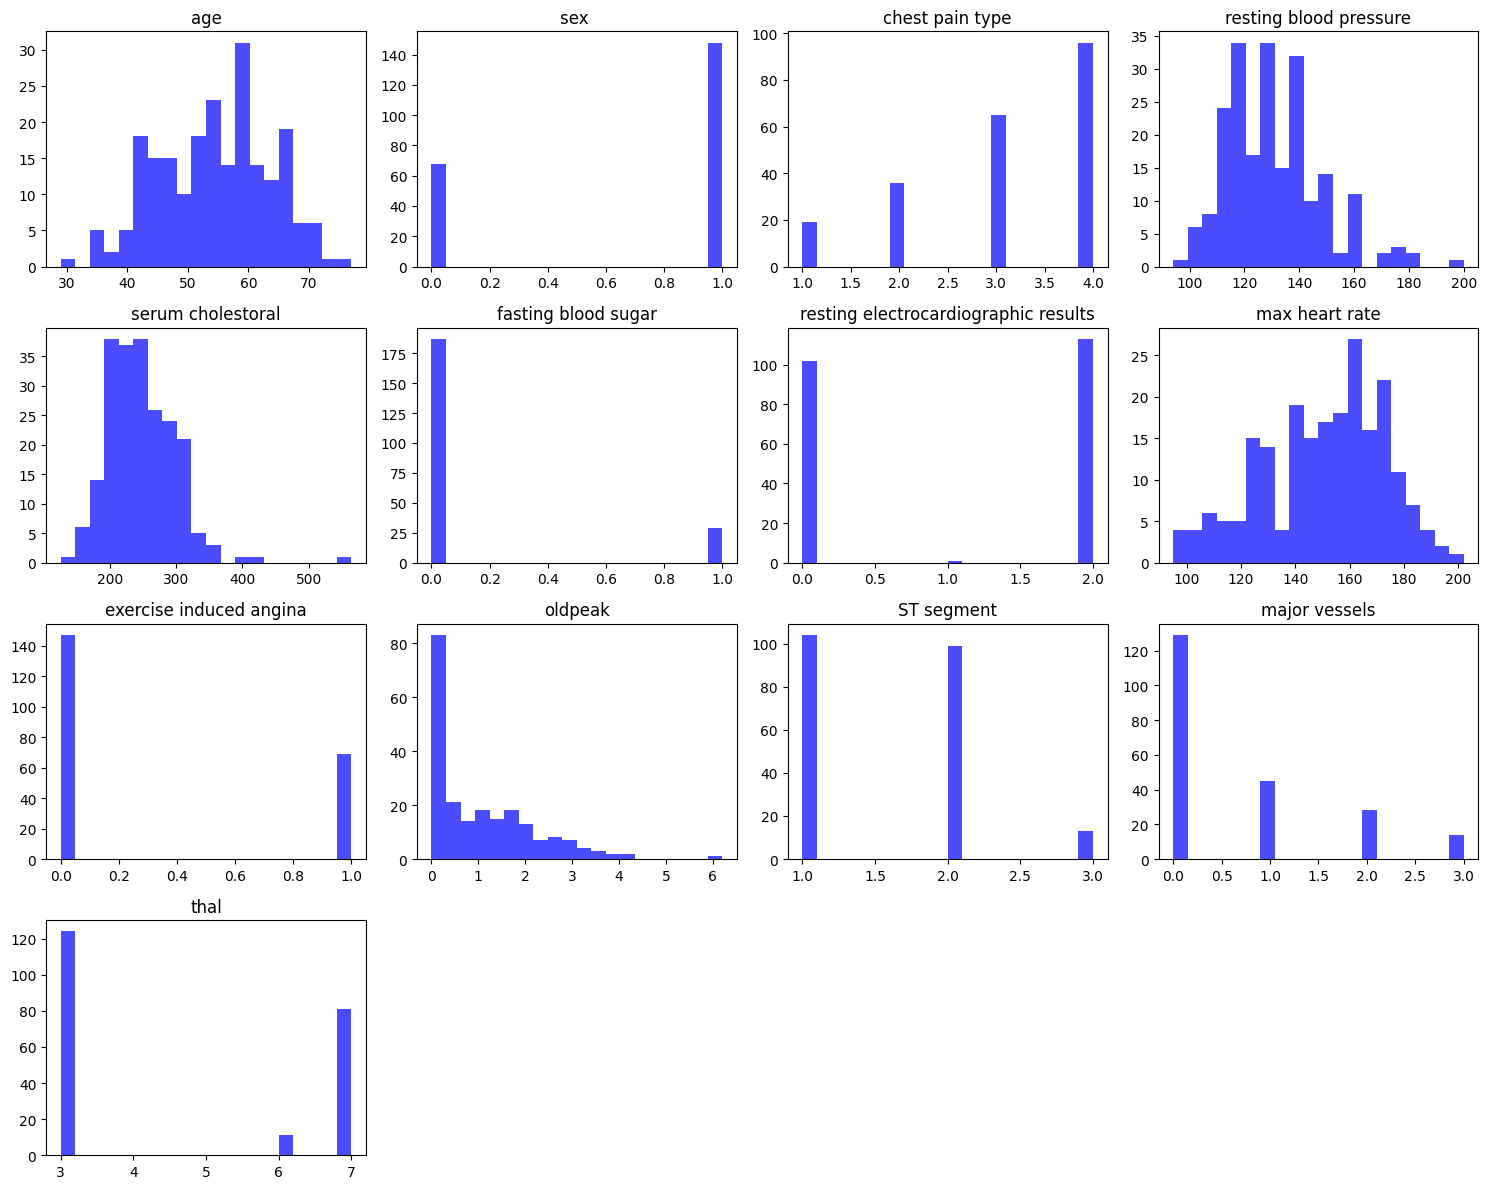

In [27]:
df_numeric = X.select_dtypes(include=['int64', 'float64'])
numeric_features = df_numeric.columns.tolist()

plt.figure(figsize=(15, 12)) 
for i, col in enumerate(numeric_features):
    plt.subplot(4, 4, i + 1)  
    plt.hist(X_train[col], bins=20, color='blue', alpha=0.7)
    plt.title(col)
    
plt.tight_layout()
plt.show()

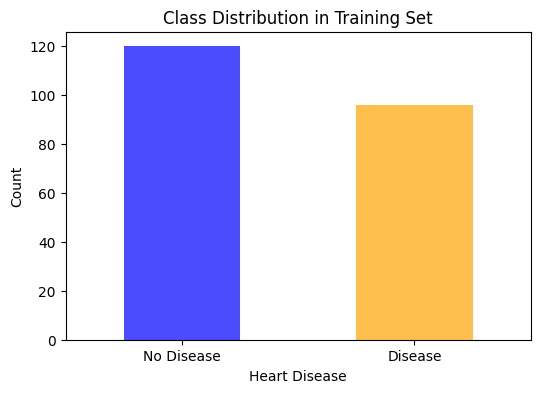

In [ ]:
plt.figure(figsize=(6, 4))
y_train.value_counts().plot(kind='bar', color=['blue', 'orange'], alpha=0.7)
plt.title('Class Distribution in Training Set')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No Disease', 'Disease'],rotation=0)
plt.show()

In [29]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)   


In [ ]:
def eval_and_report(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    metrics = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc
    }
    
    print(f"\n{name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")
    
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n  Confusion Matrix:\n{cm}")
    
    plt.figure(figsize=(6, 4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {name}')
    plt.colorbar()
    
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {name}')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return metrics

# 🌟 Exercise 2 : Logistic Regression without Grid Search


Logistic Regression without GS:
  Accuracy: 0.8519
  Precision: 0.7857
  Recall: 0.9167
  F1 Score: 0.8462
  ROC-AUC: 0.8986

  Confusion Matrix:
[[24  6]
 [ 2 22]]


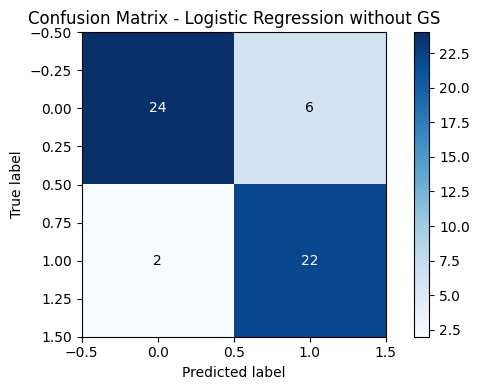

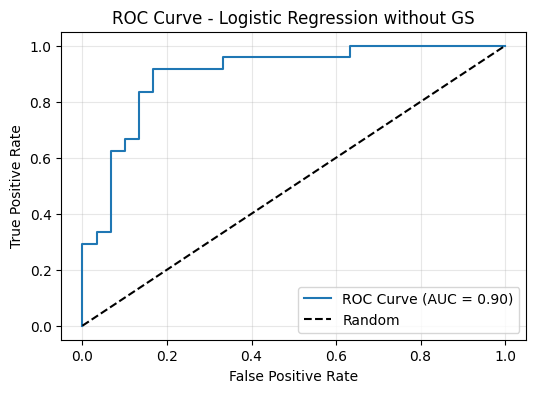

In [ ]:
y_test = y_test.replace({1: 0, 2: 1})
y_train = y_train.replace({1: 0, 2: 1}) 

pipe_lr = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE))
])
pipe_lr.fit(X_train, y_train)

lr_metrics = eval_and_report('Logistic Regression without GS', pipe_lr, X_test, y_test)


# 🌟 Exercise 3 : Logistic Regression with Grid Search

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters for Logistic Regression: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

Logistic Regression with GS:
  Accuracy: 0.8519
  Precision: 0.8333
  Recall: 0.8333
  F1 Score: 0.8333
  ROC-AUC: 0.9083

  Confusion Matrix:
[[26  4]
 [ 4 20]]


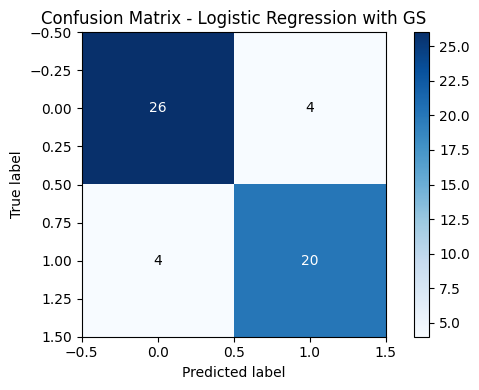

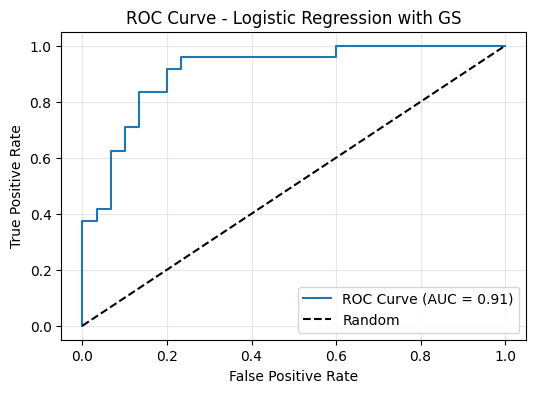

In [ ]:
pipe_lr_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE))
])
y_test = y_test.replace({1: 0, 2: 1})
y_train = y_train.replace({1: 0, 2: 1})

param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2'],  
    'classifier__solver': ['lbfgs', 'liblinear']
}
grid_lr = GridSearchCV(
    estimator=pipe_lr_cv,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_lr.fit(X_train, y_train)   
print(f"Best parameters for Logistic Regression: {grid_lr.best_params_}")
best_lr = grid_lr.best_estimator_
lr_gs_metrics = eval_and_report('Logistic Regression with GS', best_lr, X_test, y_test)

# 🌟 Exercise 4 : SVM without Grid Search


SVM without Grid Search:
  Accuracy: 0.8148
  Precision: 0.7692
  Recall: 0.8333
  F1 Score: 0.8000
  ROC-AUC: 0.8861

  Confusion Matrix:
[[24  6]
 [ 4 20]]


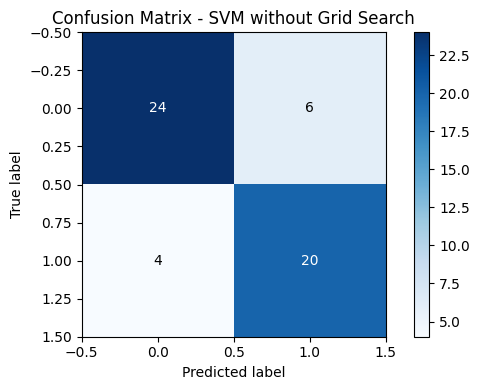

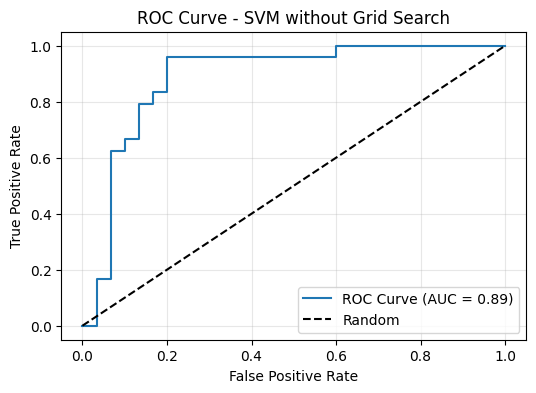

In [36]:
pipe_svc = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', SVC(probability=True, random_state=RANDOM_STATE))
])
pipe_svc.fit(X_train, y_train)
svc_metrics = eval_and_report('SVM without Grid Search', pipe_svc, X_test, y_test)


# 🌟 Exercise 5 : SVM with Grid Search

Fitting 5 folds for each of 20 candidates, totalling 100 fits


C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
25 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\sklearn\pipeline.py", line 427, in fit
    self._fina

Best parameters for Logistic Regression: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

Logistic Regression with GS:
  Accuracy: 0.8519
  Precision: 0.8333
  Recall: 0.8333
  F1 Score: 0.8333
  ROC-AUC: 0.9083

  Confusion Matrix:
[[26  4]
 [ 4 20]]


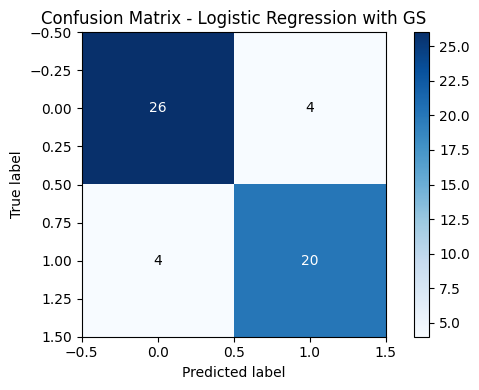

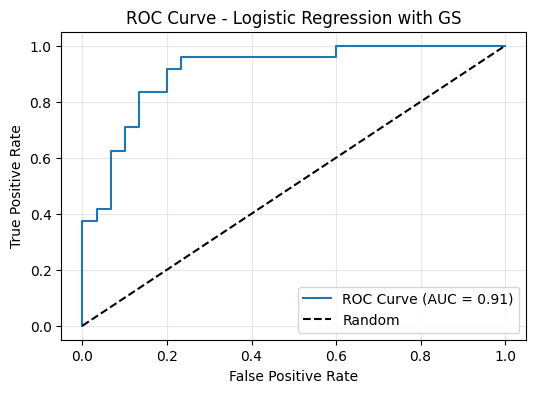

In [39]:
pipe_lr_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE))
])
param_grid = {
    'classifier__C': [0.01, 0.1, 1,10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['lbfgs', 'liblinear']
}
grid_svm = GridSearchCV(
    estimator=pipe_lr_cv,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_svm.fit(X_train, y_train)
print(f"Best parameters for Logistic Regression: {grid_svm.best_params_}")
best_svm = grid_svm.best_estimator_
lr_gs_metrics = eval_and_report('Logistic Regression with GS', best_svm, X_test, y_test)

# 🌟 Exercise 6 : XGBoost without Grid Search

C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:199: UserWarning: [19:45:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost without Grid Search:
  Accuracy: 0.8148
  Precision: 0.7692
  Recall: 0.8333
  F1 Score: 0.8000
  ROC-AUC: 0.8653

  Confusion Matrix:
[[24  6]
 [ 4 20]]


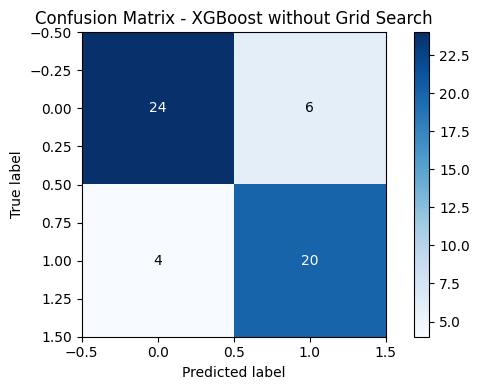

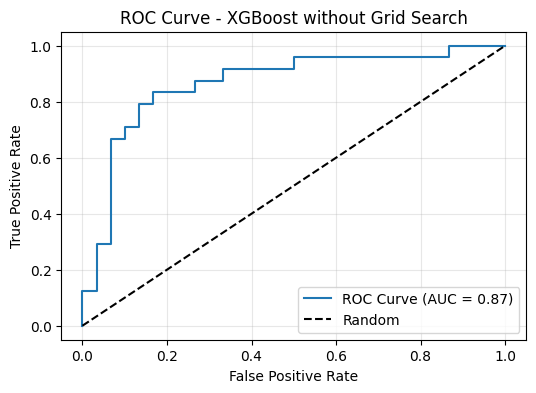

In [40]:
pipe_xgb = Pipeline(steps=[
    ('preprocessor', pre),  
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE))    
])
pipe_xgb.fit(X_train, y_train)
xgb_metrics = eval_and_report('XGBoost without Grid Search', pipe_xgb, X_test, y_test)

# 🌟 Exercise 7 : XGBoost with Grid Search

Fitting 5 folds for each of 9 candidates, totalling 45 fits


C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:199: UserWarning: [19:47:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters for XGBoost: {'classifier__max_depth': 5, 'classifier__n_estimators': 100}

XGBoost with GS:
  Accuracy: 0.8333
  Precision: 0.8000
  Recall: 0.8333
  F1 Score: 0.8163
  ROC-AUC: 0.8694

  Confusion Matrix:
[[25  5]
 [ 4 20]]


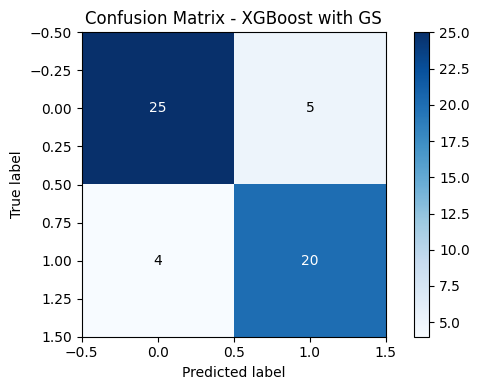

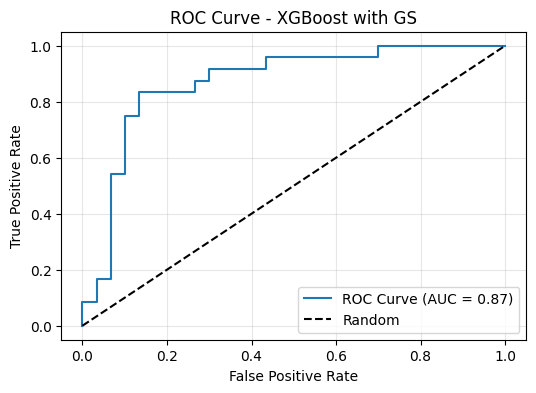

In [41]:
pipe_xgb_cv = Pipeline(steps=[
    ('preprocessor', pre),  
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE))
])

xgb_param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [3, 5, 7],
}
grid_xgb = GridSearchCV(
    estimator=pipe_xgb_cv,
    param_grid=xgb_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_xgb.fit(X_train, y_train)
print(f"Best parameters for XGBoost: {grid_xgb.best_params_}")
best_xgb = grid_xgb.best_estimator_
xgb_gs_metrics = eval_and_report('XGBoost with GS', best_xgb, X_test, y_test)